**Nama: Richie Darrian Prayogo**  
**NIM: 2802408133**

# Video Penjelasan

Link: https://www.youtube.com/watch?v=JNJbYfNctzY&list=PLOh0HbCqILkw&index=2

# Nomor 2 - Autoencoder
Dataset yang digunakan: **Stadium** dan **Oil Gas Field** - Dataset (NIM Ganjil, Laki-laki)

### Pemuatan Library

In [1]:
import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from PIL import Image
from skimage.metrics import structural_similarity as ssim
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import callbacks
from tensorflow.keras.optimizers import Adam

# Reproducibility
SEED = 1
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow version: {tf.__version__}")

2026-06-29 06:59:45.090183: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782716385.114094     120 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782716385.122458     120 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782716385.141855     120 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782716385.141877     120 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782716385.141880     120 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0


### **a. [LO 3, LO 4, 5 poin] Lakukan loading dan scaling data serta tampilkan contoh data yang digunakan. Kemudian pisahkan dataset menjadi 80% training set, 10% validation set dan 10% test set.**

### Ekstraksi dan Pemuatan Data

Dataset Overhead-MNIST yang digunakan terdiri dari dua kelas, yaitu:
- **Stadium**: citra udara stadion olahraga
- **Oil Gas Field**: citra udara ladang minyak dan gas

Setiap gambar berukuran 28×28 piksel dalam skala grayscale (1 channel), yang kemudian akan di-*flatten* menjadi vektor berdimensi 784 sebagai input Autoencoder.

In [ ]:
import os

BASE_DIR = '/kaggle/input/datasets/datamunge/overheadmnist/version2'

TARGET_CLASSES = ['stadium', 'oil_gas_field']

TRAIN_DIR = os.path.join(BASE_DIR, 'train')
TEST_DIR = os.path.join(BASE_DIR, 'test')

print("Train dir:", os.listdir(TRAIN_DIR))
print("Test dir:", os.listdir(TEST_DIR))


Train dir: ['ship', 'helicopter', 'car', 'parking_lot', 'oil_gas_field', 'harbor', 'plane', 'stadium', 'storage_tank', 'runway_mark']
Test dir: ['ship', 'helicopter', 'car', 'parking_lot', 'oil_gas_field', 'harbor', 'plane', 'stadium', 'storage_tank', 'runway_mark']


In [ ]:
def load_images_from_dir(base_dir, class_name, label):
    """
    Membaca semua gambar dari direktori training dan testing
    untuk satu kelas tertentu, lalu mengembalikan array numpy.
    """
    images = []
    labels = []
    
    for split in ['train', 'test']:
        folder = os.path.join(base_dir, split, class_name)
        if not os.path.exists(folder):
            continue
        for fname in os.listdir(folder):
            if fname.lower().endswith(('.jpg', '.png', '.jpeg')):
                img_path = os.path.join(folder, fname)
                img = Image.open(img_path).convert('L')  # Grayscale
                img = img.resize((28, 28))
                images.append(np.array(img))
                labels.append(label)
    
    return np.array(images), np.array(labels)

# Muat kedua kelas
X_stadium, y_stadium = load_images_from_dir(BASE_DIR, 'stadium', 0)
X_oil, y_oil = load_images_from_dir(BASE_DIR, 'oil_gas_field', 1)

print(f"Jumlah gambar Stadium     : {len(X_stadium)}")
print(f"Jumlah gambar Oil Gas Field: {len(X_oil)}")

Jumlah gambar Stadium     : 7596
Jumlah gambar Oil Gas Field: 7993


In [4]:
# Gabungkan kedua kelas
X_all = np.concatenate([X_stadium, X_oil], axis=0)
y_all = np.concatenate([y_stadium, y_oil], axis=0)

print(f"Total gambar keseluruhan   : {X_all.shape[0]}")
print(f"Shape tiap gambar          : {X_all.shape[1:]}")

Total gambar keseluruhan   : 15589
Shape tiap gambar          : (28, 28)


### Scaling Data

Karena setiap piksel dalam citra grayscale memiliki nilai integer dari 0 hingga 255, maka dilakukan normalisasi dengan membagi nilainya dengan 255.0 sehingga rentang nilai menjadi [0, 1]. Normalisasi ini penting agar:
- Gradien tidak terlalu besar atau terlalu kecil selama proses pelatihan.
- Activation function Sigmoid yang digunakan pada layer akhir decoder dapat bekerja secara optimal (karena outputnya juga berada di rentang [0, 1]).

In [5]:
# Normalisasi ke [0, 1]
X_all_norm = X_all.astype('float32') / 255.0

print(f"Nilai piksel sebelum normalisasi: min={X_all.min()}, max={X_all.max()}")
print(f"Nilai piksel setelah normalisasi : min={X_all_norm.min():.1f}, max={X_all_norm.max():.1f}")

Nilai piksel sebelum normalisasi: min=0, max=255
Nilai piksel setelah normalisasi : min=0.0, max=1.0


### Tampilan Contoh Data

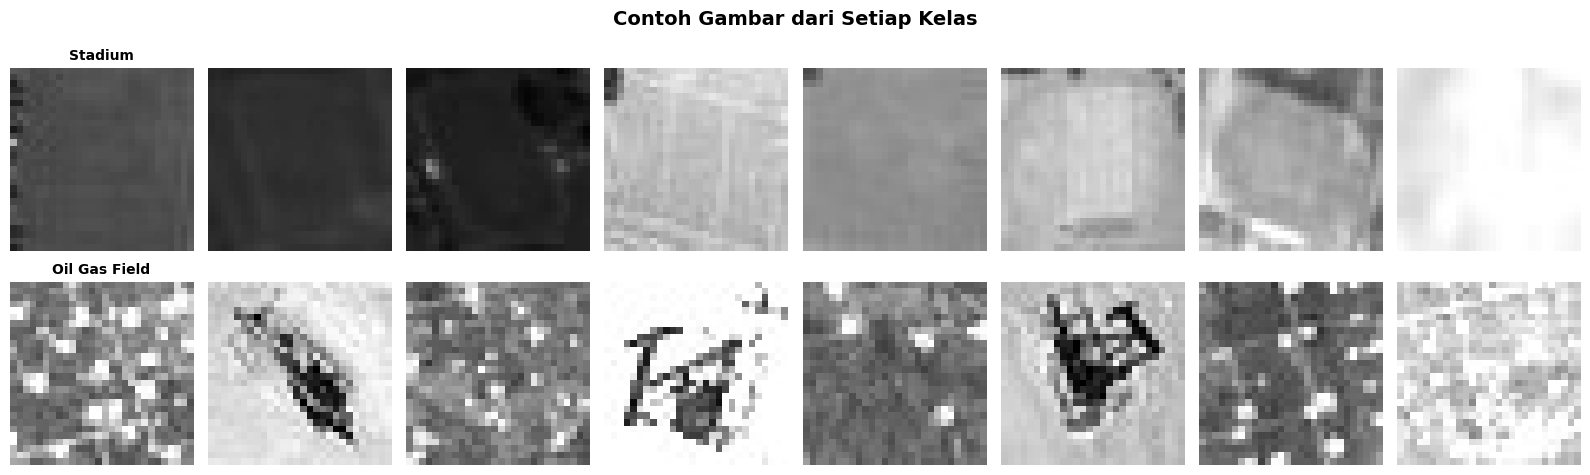

In [6]:
class_names = {0: 'Stadium', 1: 'Oil Gas Field'}

fig, axes = plt.subplots(2, 8, figsize=(16, 5))
fig.suptitle('Contoh Gambar dari Setiap Kelas', fontsize=14, fontweight='bold')

for row, (class_id, class_label) in enumerate(class_names.items()):
    indices = np.where(y_all == class_id)[0][:8]
    for col, idx in enumerate(indices):
        axes[row, col].imshow(X_all_norm[idx], cmap='gray', vmin=0, vmax=1)
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_title(class_label, fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

Dari visualisasi di atas terlihat perbedaan karakteristik tekstur antara kedua kelas:
- **Stadium** cenderung memiliki pola oval atau segiempat yang dominan dengan kontras yang lebih rendah.
- **Oil Gas Field** memiliki pola lebih kompleks dengan banyak objek bulat kecil-kecil dan distribusi intensitas yang lebih merata.

### Pembagian Dataset: 80% Training, 10% Validation, 10% Test

Dataset dibagi menjadi tiga bagian dengan strategi sebagai berikut:
1. Pisahkan dahulu 80% data untuk training dan 20% sisanya.
2. Dari 20% yang tersisa, bagi menjadi dua bagian yang sama rata (10% validation dan 10% test).

Karena Autoencoder adalah model *unsupervised learning* untuk rekonstruksi, label kelas (`y`) hanya disimpan untuk keperluan analisis distribusi, bukan untuk pelatihan. Yang menjadi input sekaligus target adalah gambar itu sendiri.

In [7]:
# Flatten gambar: (N, 28, 28) -> (N, 784) untuk Autoencoder Dense
X_flat = X_all_norm.reshape(X_all_norm.shape[0], -1)

# Pembagian pertama: 80% train, 20% sisanya
X_train, X_temp, y_train, y_temp = train_test_split(
    X_flat, y_all,
    test_size=0.2,
    random_state=SEED,
    stratify=y_all
)

# Pembagian kedua: bagi sisa 20% menjadi 10% val dan 10% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=SEED,
    stratify=y_temp
)

print(f"Ukuran Training Set   : {X_train.shape[0]} gambar ({X_train.shape[0]/X_flat.shape[0]*100:.1f}%)")
print(f"Ukuran Validation Set : {X_val.shape[0]} gambar ({X_val.shape[0]/X_flat.shape[0]*100:.1f}%)")
print(f"Ukuran Test Set       : {X_test.shape[0]} gambar ({X_test.shape[0]/X_flat.shape[0]*100:.1f}%)")
print(f"\nDimensi input (per gambar) : {X_train.shape[1]}")

Ukuran Training Set   : 12471 gambar (80.0%)
Ukuran Validation Set : 1559 gambar (10.0%)
Ukuran Test Set       : 1559 gambar (10.0%)

Dimensi input (per gambar) : 784


In [ ]:
# Verifikasi distribusi kelas pada setiap split
splits = {'Training': y_train, 'Validation': y_val, 'Test': y_test}

print("Distribusi kelas per split:")
print(f"{'Split':<15} {'Stadium':>10} {'Oil Gas Field':>15}")
print("-" * 42)
for split_name, labels in splits.items():
    n_stadium = np.sum(labels == 0)
    n_oil = np.sum(labels == 1)
    print(f"{split_name:<15} {n_stadium:>10} {n_oil:>15}")

Distribusi kelas per split:
Split              Stadium   Oil Gas Field
------------------------------------------
Training              6077            6394
Validation             760             799
Test                   759             800


Distribusi kelas pada setiap split terlihat seimbang karena digunakan stratified splitting, memastikan proporsi kelas Stadium dan Oil Gas Field tetap konsisten di seluruh split.

### b. **[LO 3, LO 4, 10 poin] Buatlah arsitektur baseline untuk Dimension Reduction dari dimensi 784 (28x28) menjadi dimensi 128, sesuai dengan gambar arsitektur Autoencoder berikut ini. Lakukan evaluasi kualitas citra hasil decoder menggunakan Structural Similarity Index (SSIM) pada data test.**
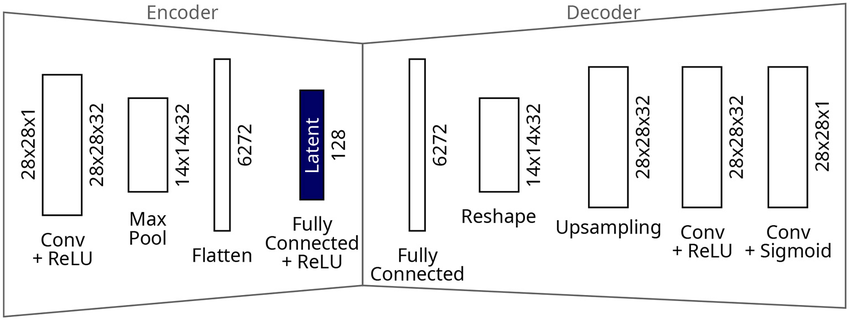


Arsitektur Autoencoder baseline yang dibangun melakukan *dimension reduction* dari dimensi **784** (gambar 28×28) menjadi **128** (latent space)

**Encoder:**
1. Input: 28×28×1
2. Conv + ReLU -> 28×28×32
3. MaxPooling -> 14×14×32
4. Flatten -> 6272
5. Fully Connected + ReLU -> 128 (Latent Space)

**Decoder:**
1. Fully Connected -> 6272
2. Reshape -> 14×14×32
3. Upsampling -> 28×28×32
4. Conv + ReLU -> 28×28×32
5. Conv + Sigmoid -> 28×28×1 (output rekonstruksi)

In [ ]:
# Reshape kembali ke (N, 28, 28, 1) untuk model Convolutional
X_train_cnn = X_train.reshape(-1, 28, 28, 1)
X_val_cnn = X_val.reshape(-1, 28, 28, 1)
X_test_cnn = X_test.reshape(-1, 28, 28, 1)

print(f"Shape X_train_cnn : {X_train_cnn.shape}")
print(f"Shape X_val_cnn   : {X_val_cnn.shape}")
print(f"Shape X_test_cnn  : {X_test_cnn.shape}")

Shape X_train_cnn : (12471, 28, 28, 1)
Shape X_val_cnn   : (1559, 28, 28, 1)
Shape X_test_cnn  : (1559, 28, 28, 1)


In [ ]:
def build_baseline_autoencoder(latent_dim=128):
    """
    Membangun Convolutional Autoencoder baseline.
    Encoder: Conv+ReLU -> MaxPool -> Flatten -> FC+ReLU (latent)
    Decoder: FC -> Reshape -> Upsampling -> Conv+ReLU -> Conv+Sigmoid
    """
    # === ENCODER ===
    encoder_input = keras.Input(shape=(28, 28, 1), name='encoder_input')
    
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same', name='conv1')(encoder_input)
    x = layers.MaxPooling2D((2, 2), padding='same', name='maxpool1')(x)   # 14x14x32
    x = layers.Flatten(name='flatten')(x)                                  # 6272
    latent = layers.Dense(latent_dim, activation='relu', name='latent')(x) # 128
    
    encoder = Model(encoder_input, latent, name='Encoder')
    
    # === DECODER ===
    decoder_input = keras.Input(shape=(latent_dim,), name='decoder_input')
    
    x = layers.Dense(6272, activation='relu', name='fc_decode')(decoder_input) # 6272
    x = layers.Reshape((14, 14, 32), name='reshape')(x)                         # 14x14x32
    x = layers.UpSampling2D((2, 2), name='upsample')(x)                         # 28x28x32
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same', name='conv2')(x)
    decoded = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same', name='output')(x) # 28x28x1
    
    decoder = Model(decoder_input, decoded, name='Decoder')
    
    # === AUTOENCODER (Encoder + Decoder) ===
    autoencoder_input = keras.Input(shape=(28, 28, 1), name='autoencoder_input')
    encoded = encoder(autoencoder_input)
    reconstructed = decoder(encoded)
    autoencoder = Model(autoencoder_input, reconstructed, name='Baseline_Autoencoder')
    
    return autoencoder, encoder, decoder

baseline_ae, baseline_encoder, baseline_decoder = build_baseline_autoencoder(latent_dim=128)

baseline_ae.summary()

I0000 00:00:1782716502.277657     120 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782716502.283704     120 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "Baseline_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ autoencoder_input (InputLayer)  │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Encoder (Functional)            │ (None, 128)            │       803,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Decoder (Functional)            │ (None, 28, 28, 1)      │       818,625 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,621,889 (6.19 MB)

 Trainable params: 1,621,889 (6.19 MB)

 Non-trainable params: 0 (0.00 B)

### Pelatihan Baseline Autoencoder

Model dikompilasi menggunakan optimizer **Adam** dengan learning rate default dan fungsi loss **Binary Crossentropy**, yang cocok digunakan ketika nilai piksel sudah dinormalisasi ke [0, 1] dan layer output menggunakan aktivasi Sigmoid.

In [ ]:
# Train one baseline autoencoder per class
baseline_models = {}
baseline_histories = {}

for class_id in sorted(np.unique(y_train)):
    ae, encoder, decoder = build_baseline_autoencoder(latent_dim=128)
    ae.compile(optimizer=Adam(learning_rate=1e-3), loss='binary_crossentropy')
    Xtr = X_train_cnn[y_train==class_id]
    Xval = X_val_cnn[y_val==class_id]
    cb=[EarlyStopping(monitor='val_loss',patience=10,restore_best_weights=True,verbose=1)]
    hist=ae.fit(Xtr,Xtr,validation_data=(Xval,Xval),epochs=100,batch_size=32,callbacks=cb,verbose=1)
    baseline_models[class_id]=ae
    baseline_histories[class_id]=hist

Epoch 1/100


I0000 00:00:1782716505.541843     188 service.cc:152] XLA service 0x7b35c800c220 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782716505.541880     188 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1782716505.541884     188 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1782716505.994981     188 cuda_dnn.cc:529] Loaded cuDNN version 91002


 50/190 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6738

I0000 00:00:1782716508.660836     188 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


190/190 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - loss: 0.6166 - val_loss: 0.6045
Epoch 2/100
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5952 - val_loss: 0.5993
Epoch 3/100
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5916 - val_loss: 0.5972
Epoch 4/100
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5897 - val_loss: 0.5963
Epoch 5/100
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5887 - val_loss: 0.5947
Epoch 6/100
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5880 - val_loss: 0.5941
Epoch 7/100
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5871 - val_loss: 0.5934
Epoch 8/100
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5868 - val_loss: 0.5928
Epoch 9/100
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5872 - val_loss: 0.5934
Epoch 10/100
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5864 - val_loss: 0.5927
Epoch 11/100
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5858 - val_loss: 0.5923
Epoch 12/100
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/ste

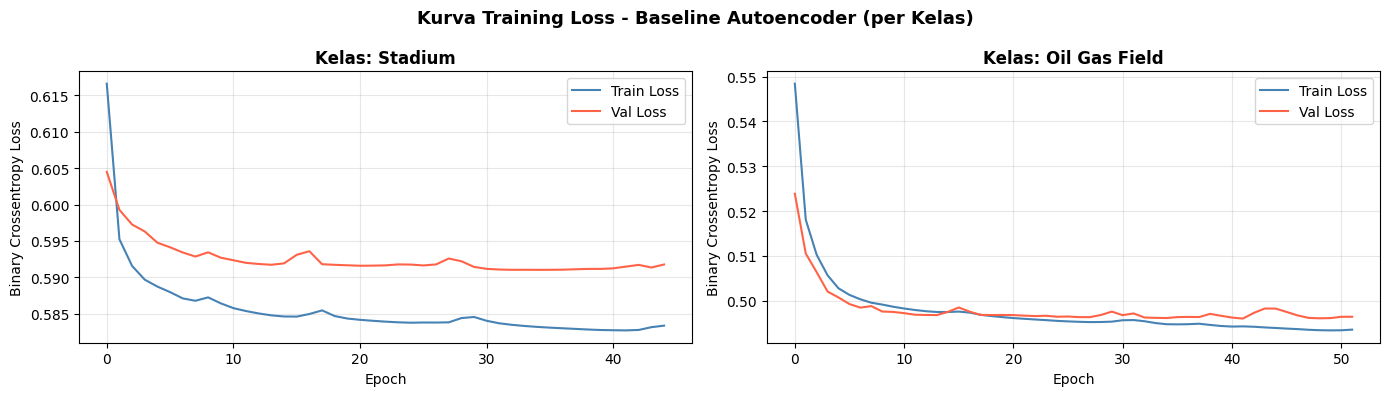

In [25]:
# Plot kurva training loss - Baseline (per kelas)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Kurva Training Loss - Baseline Autoencoder (per Kelas)', fontsize=13, fontweight='bold')

for ax, (class_id, hist) in zip(axes, baseline_histories.items()):
    ax.plot(hist.history['loss'],     label='Train Loss', color='steelblue')
    ax.plot(hist.history['val_loss'], label='Val Loss',   color='tomato')
    ax.set_title(f'Kelas: {class_names[class_id]}', fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Binary Crossentropy Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Evaluasi Baseline: SSIM pada Test Set

**Structural Similarity Index (SSIM)** adalah metrik yang mengukur kemiripan antara dua gambar dari perspektif persepsi manusia. SSIM mempertimbangkan tiga aspek:
1. **Luminance** (kecerahan)
2. **Contrast** (kontras)
3. **Structure** (struktur)

Nilai SSIM berkisar dari -1 hingga 1, di mana nilai mendekati 1 berarti rekonstruksi sangat mirip dengan gambar asli.

In [13]:
def compute_ssim_scores(models, X_test_input, y_test_labels):
    X_reconstructed=np.zeros_like(X_test_input)
    for class_id,model in models.items():
        idx=np.where(y_test_labels==class_id)[0]
        if len(idx):
            X_reconstructed[idx]=model.predict(X_test_input[idx],verbose=0)
    ssim_scores=[]
    for i in range(len(X_test_input)):
        s=ssim(X_test_input[i,:,:,0],X_reconstructed[i,:,:,0],data_range=1.0)
        ssim_scores.append(s)
    return np.array(ssim_scores),X_reconstructed


In [ ]:
def visualize_reconstruction(X_original, X_reconstructed, y_labels, class_names, ssim_scores=None, n=8, title='Rekonstruksi'):
    """
    Menampilkan perbandingan gambar asli vs rekonstruksi per kelas.
    Setiap kolom diberi header 'Asli' / 'Rekonstruksi'.
    Jika ssim_scores diberikan, nilai SSIM ditampilkan di bawah setiap rekonstruksi.
    """
    n_rows = 4          # 2 baris per kelas: (Asli, Rekonstruksi) x 2 kelas
    fig, axes = plt.subplots(n_rows, n, figsize=(n * 2, n_rows * 2.4))
    fig.suptitle(title, fontsize=13, fontweight='bold', y=1.01)

    row_titles = {
        0: ('Stadium — Asli',          'Stadium — Rekonstruksi'),
        1: ('Oil Gas Field — Asli',    'Oil Gas Field — Rekonstruksi'),
    }

    for i, class_id in enumerate([0, 1]):
        idx_class = np.where(y_labels == class_id)[0][:n]
        title_asli, title_rekon = row_titles[class_id]

        for j, idx in enumerate(idx_class):
            # baris Asli
            ax_orig = axes[i * 2, j]
            ax_orig.imshow(X_original[idx, :, :, 0], cmap='gray', vmin=0, vmax=1)
            ax_orig.axis('off')
            if j == 0:
                ax_orig.set_ylabel(title_asli, fontsize=8, fontweight='bold', rotation=90, labelpad=4)
            ax_orig.set_title('Asli', fontsize=7, color='steelblue', pad=2)

            # baris Rekonstruksi
            ax_rec = axes[i * 2 + 1, j]
            ax_rec.imshow(X_reconstructed[idx, :, :, 0], cmap='gray', vmin=0, vmax=1)
            ax_rec.axis('off')
            if j == 0:
                ax_rec.set_ylabel(title_rekon, fontsize=8, fontweight='bold', rotation=90, labelpad=4)
            if ssim_scores is not None:
                ax_rec.set_title(f'SSIM: {ssim_scores[idx]:.3f}', fontsize=7, color='tomato', pad=2)
            else:
                ax_rec.set_title('Rekonstruksi', fontsize=7, color='tomato', pad=2)

    plt.tight_layout()
    plt.show()

In [27]:
# Hitung SSIM baseline pada test set
ssim_baseline, X_test_recon_baseline = compute_ssim_scores(baseline_models, X_test_cnn, y_test)

print('=' * 50)
print('SSIM Baseline - Keseluruhan')
print('=' * 50)
print(f'  Mean : {ssim_baseline.mean():.4f}')
print(f'  Std  : {ssim_baseline.std():.4f}')
print(f'  Min  : {ssim_baseline.min():.4f}')
print(f'  Max  : {ssim_baseline.max():.4f}')

print()
print('SSIM Baseline - Per Kelas')
print('-' * 50)
for class_id, class_label in class_names.items():
    idx = np.where(y_test == class_id)[0]
    s   = ssim_baseline[idx]
    print(f'  {class_label:<15} Mean={s.mean():.4f}  Std={s.std():.4f}  '
          f'Min={s.min():.4f}  Max={s.max():.4f}')

SSIM Baseline - Keseluruhan
  Mean : 0.4903
  Std  : 0.2296
  Min  : 0.0427
  Max  : 0.9783

SSIM Baseline - Per Kelas
--------------------------------------------------
  Stadium         Mean=0.6753  Std=0.1328  Min=0.3140  Max=0.9783
  Oil Gas Field   Mean=0.3148  Std=0.1507  Min=0.0427  Max=0.7557


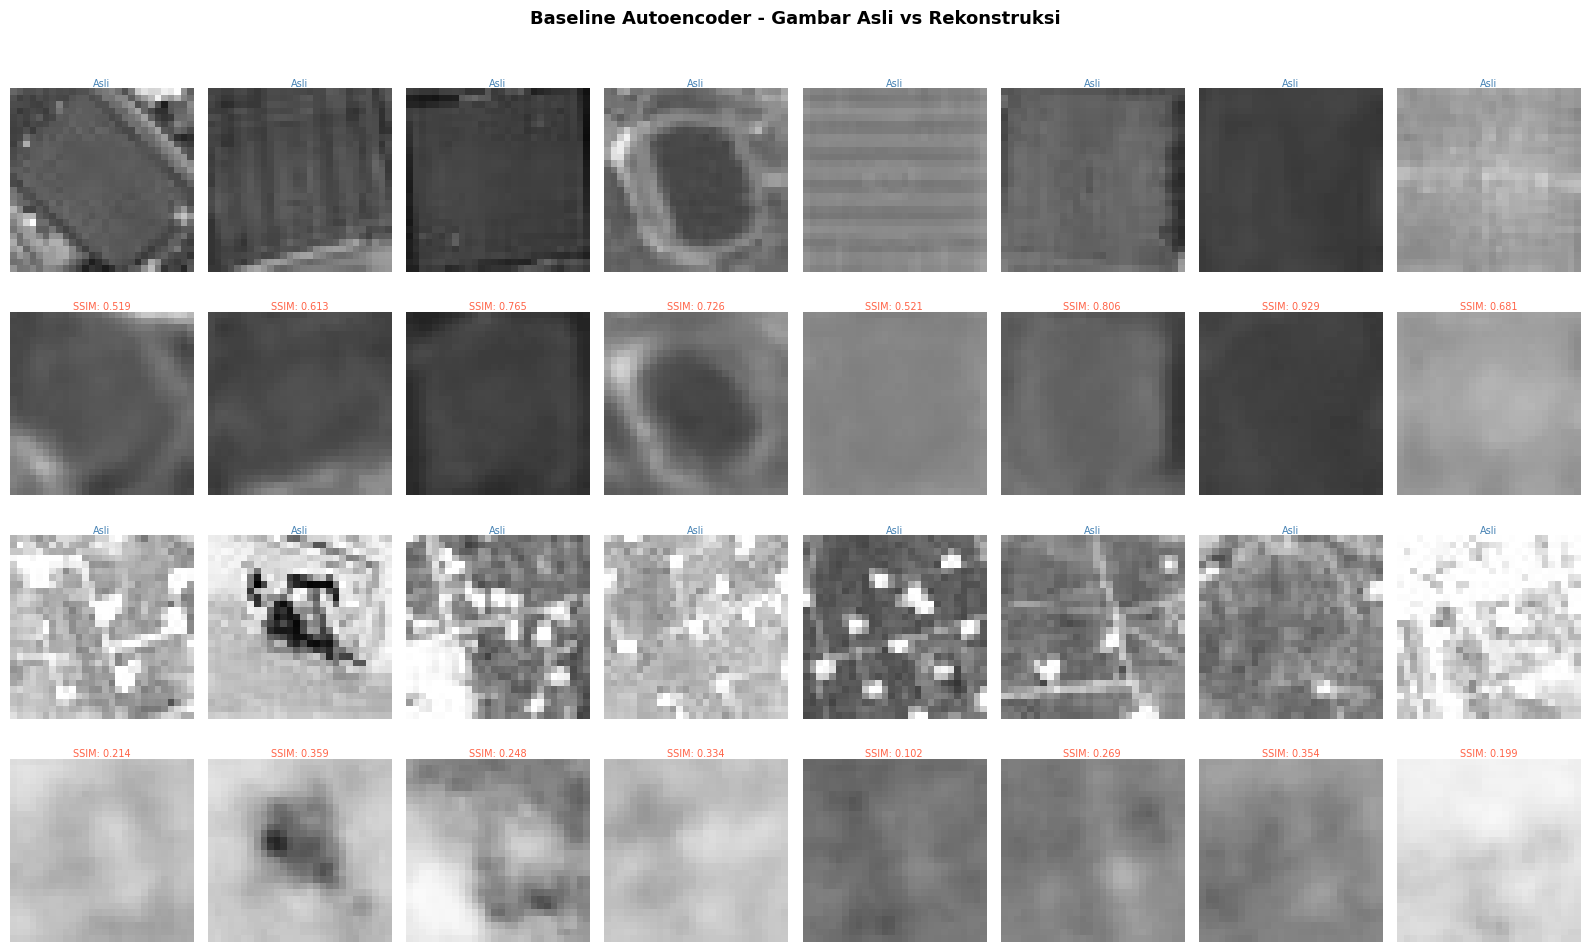

In [26]:
visualize_reconstruction(
    X_test_cnn, X_test_recon_baseline, y_test, class_names,
    ssim_scores=ssim_baseline,
    title='Baseline Autoencoder - Gambar Asli vs Rekonstruksi'
)

Dari hasil visualisasi di atas, terlihat bahwa:
- Label **"Asli"** (biru) menunjukkan gambar input asli dari test set, sedangkan label **"Rekonstruksi"** (merah) menunjukkan output decoder. Nilai SSIM per gambar ditampilkan di bawah setiap hasil rekonstruksi.
- Rekonstruksi baseline sudah cukup menangkap bentuk umum dari masing-masing kelas (pola oval untuk Stadium, distribusi titik untuk Oil Gas Field).
- Namun, rekonstruksi masih tampak *blurry* (buram) karena dengan hanya satu Conv layer di encoder dan tanpa Conv refine di decoder, model tidak mampu menangkap detail tekstur halus, terutama pada gambar Oil Gas Field yang memiliki pola lebih kompleks.

### **c. [LO 1, LO 2, LO 3, LO 4, 10 poin] Setelah mengetahui hasil dari nomor (2b), modifikasi arsitektur Autoencoder di atas agar mendapatkan representasi Dimension Reduction yang optimal dengan membandingkan hasil Structural Similarity Index (SSIM) nya. Dan selanjutnya lakukan proses tuning hyperparameter agar unjuk kerjanya meningkat. Berikan alasan mengapa modifikasi arsitektur dan metode tuning hyperparameter kalian lebih baik.**

Berdasarkan hasil baseline, dilakukan beberapa modifikasi utama untuk meningkatkan kualitas rekonstruksi citra berdasarkan nilai SSIM:
1. Menambahkan **Conv2D refinement pada decoder** (`add_decoder_refine`) setelah proses **UpSampling** untuk memperhalus detail tekstur sebelum menghasilkan citra keluaran, karena proses upsampling saja sering menghasilkan rekonstruksi yang masih kasar dan kehilangan detail spasial, terutama pada pola kompleks seperti **Oil Gas Field**.
2. Menambahkan **Conv2D refinement pada encoder** (`add_encoder_refine`, opsional) setelah **MaxPooling** agar encoder dapat mengekstraksi representasi fitur yang lebih kaya sebelum memasuki bottleneck sehingga informasi penting mengenai struktur dan tekstur citra dapat dipertahankan dengan lebih baik selama proses kompresi.
3. Menggunakan **kombinasi loss MSE dan SSIM** sebagai fungsi objektif pelatihan karena **MSE** berfokus pada meminimalkan kesalahan nilai piksel secara rata-rata, sedangkan **SSIM** mengevaluasi kesamaan struktur, kontras, dan luminansi citra. Kombinasi keduanya memungkinkan autoencoder menghasilkan rekonstruksi yang tidak hanya akurat secara numerik tetapi juga lebih baik secara visual.
4. Mengubah mekanisme **EarlyStopping** untuk memonitor **validation SSIM** dibandingkan hanya **validation loss** karena metrik utama yang digunakan untuk mengevaluasi kualitas rekonstruksi adalah SSIM. Dengan demikian, model terbaik dipilih berdasarkan kemampuan mempertahankan struktur visual citra, bukan semata-mata menghasilkan nilai loss terendah.
5. Menambahkan **ReduceLROnPlateau** yang mengurangi **learning rate sebesar 0,5×** ketika **validation loss** tidak mengalami peningkatan selama beberapa epoch dengan batas minimum **1 × 10⁻⁷** sehingga proses optimasi dapat melanjutkan pencarian solusi yang lebih baik setelah pelatihan mulai stagnan dan mengurangi risiko berhenti pada solusi suboptimal.
6. Melakukan **sweep terhadap beberapa kombinasi konfigurasi** (encoder refinement, decoder refinement, serta penggunaan loss MSE+SSIM) untuk memperoleh arsitektur yang memberikan keseimbangan terbaik antara kompleksitas model dan kualitas rekonstruksi pada dataset **Overhead-MNIST** yang berukuran relatif kecil.

In [17]:
# === Helper: SSIM metric & custom loss =======================================

def tf_ssim_metric(y_true, y_pred):
    """SSIM metric untuk Keras — scalar mean per batch."""
    return tf.reduce_mean(tf.image.ssim(y_true, y_pred, max_val=1.0))

def weighted_mse_ssim_loss(y_true, y_pred, ssim_weight=0.015):
    """MSE + weighted (1 - SSIM). Gabungan pixel-level dan perceptual loss."""
    mse  = tf.reduce_mean(tf.square(y_true - y_pred))
    ssim = tf.reduce_mean(tf.image.ssim(y_true, y_pred, max_val=1.0))
    return mse + ssim_weight * (1.0 - ssim)

In [ ]:
# === Arsitektur Improved Autoencoder =========================================
def build_improved_autoencoder(latent_dim=128, filters=32, add_encoder_refine=False, add_decoder_refine=True):
    """
    Improved Autoencoder - lightweight baseline-plus untuk Overhead-MNIST.

    Tetap 1x downsampling (28x28 -> 14x14), latent 128 sesuai soal.
    Tambahan Conv refine opsional di encoder/decoder untuk detail lebih tajam.
    """
    # === ENCODER ===
    encoder_input = keras.Input(shape=(28, 28, 1), name='encoder_input')
    x = layers.Conv2D(filters, (3, 3), activation='relu', padding='same', name='enc_conv1')(encoder_input)
    x = layers.MaxPooling2D((2, 2), name='enc_pool')(x)           # 14x14xF
    if add_encoder_refine:
        x = layers.Conv2D(filters, (3, 3), activation='relu', padding='same', name='enc_refine_conv')(x)
    x = layers.Flatten(name='enc_flatten')(x)
    latent = layers.Dense(latent_dim, activation='relu', name=f'latent_{latent_dim}')(x)
    encoder = Model(encoder_input, latent, name='improved_encoder')

    # === DECODER ===
    decoder_input = keras.Input(shape=(latent_dim,), name='decoder_input')
    x = layers.Dense(14 * 14 * filters, activation='relu', name='dec_dense')(decoder_input)
    x = layers.Reshape((14, 14, filters), name='dec_reshape')(x)
    x = layers.UpSampling2D((2, 2), name='dec_upsampling')(x)     # 28x28xF
    x = layers.Conv2D(filters, (3, 3), activation='relu', padding='same', name='dec_conv1')(x)
    if add_decoder_refine:
        x = layers.Conv2D(filters, (3, 3), activation='relu', padding='same', name='dec_refine_conv')(x)
    decoder_output = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same', name='decoder_output')(x)
    decoder = Model(decoder_input, decoder_output, name='improved_decoder')

    # === AUTOENCODER ===
    ae_out = decoder(encoder(encoder_input))
    autoencoder = Model(encoder_input, ae_out, name='improved_autoencoder')
    return autoencoder, encoder, decoder


# Sanity check
_ae, _enc, _ = build_improved_autoencoder()
assert _enc.output_shape == (None, 128),    'Latent dim harus 128.'
assert _ae.output_shape  == (None, 28, 28, 1), 'Output harus 28x28x1.'
del _ae, _enc

print('=' * 70)
print('IMPROVED AUTOENCODER: lightweight baseline-plus, 784 -> 128 -> 784')
print('=' * 70)
build_improved_autoencoder()[0].summary()

IMPROVED AUTOENCODER: lightweight baseline-plus, 784 -> 128 -> 784


Model: "improved_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ improved_encoder (Functional)   │ (None, 128)            │       803,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ improved_decoder (Functional)   │ (None, 28, 28, 1)      │       827,873 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,631,137 (6.22 MB)

 Trainable params: 1,631,137 (6.22 MB)

 Non-trainable params: 0 (0.00 B)

### Tuning Hyperparameter

Tiga konfigurasi di-sweep, masing-masing dilatih **per kelas** (Stadium & Oil Gas Field secara terpisah) mengikuti pola baseline:

| Config | Enc Refine | Loss | lr |
|--------|------------|------|----|
| Improved-A | ✗ | MSE | 1e-3 |
| Improved-B | ✗ | MSE+SSIM | 5e-4 |
| Improved-C | ✓ | MSE+SSIM | 5e-4 |

- **Improved-A**: titik referensi. Dec refine dengan MSE standar, lr sama dengan baseline.
- **Improved-B**: tambah SSIM loss dengan lr lebih kecil agar konvergensi lebih stabil.
- **Improved-C**: encoder lebih kaya fitur (tambah enc refine) dengan SSIM loss.

In [ ]:
# === Hyperparameter Tuning - Per Kelas =======================================

configs = [
    {
        'name': 'Improved-A | F=32 | DecRefine | MSE | lr=1e-3 | bs=32',
        'filters': 32, 'add_encoder_refine': False, 'add_decoder_refine': True,
        'loss': 'mse', 'lr': 1e-3, 'batch_size': 32,
    },
    {
        'name': 'Improved-B | F=32 | DecRefine | MSE+SSIM | lr=5e-4 | bs=32',
        'filters': 32, 'add_encoder_refine': False, 'add_decoder_refine': True,
        'loss': weighted_mse_ssim_loss, 'lr': 5e-4, 'batch_size': 32,
    },
    {
        'name': 'Improved-C | F=32 | Enc+DecRefine | MSE+SSIM | lr=5e-4 | bs=32',
        'filters': 32, 'add_encoder_refine': True, 'add_decoder_refine': True,
        'loss': weighted_mse_ssim_loss, 'lr': 5e-4, 'batch_size': 32,
    },
]

tuning_results = []

for config in configs:
    print(f"\n{'=' * 90}")
    print(f"Training: {config['name']}")
    print(f"{'=' * 90}")

    config_models    = {}
    config_histories = {}

    for class_id in sorted(np.unique(y_train)):
        print(f"\n  → Kelas {class_id} ({class_names[class_id]})")

        ae_model, enc_model, dec_model = build_improved_autoencoder(
            latent_dim=128,
            filters=config['filters'],
            add_encoder_refine=config['add_encoder_refine'],
            add_decoder_refine=config['add_decoder_refine'],
        )
        ae_model.compile(
            optimizer=Adam(learning_rate=config['lr']),
            loss=config['loss'],
            metrics=[tf_ssim_metric],
        )

        Xtr  = X_train_cnn[y_train == class_id]
        Xval = X_val_cnn[y_val   == class_id]

        tuning_callbacks = [
            callbacks.EarlyStopping(
                monitor='val_tf_ssim_metric', mode='max',
                patience=10, restore_best_weights=True, verbose=1,
            ),
            callbacks.ReduceLROnPlateau(
                monitor='val_loss', factor=0.5,
                patience=4, min_lr=1e-7, verbose=1,
            ),
        ]

        hist = ae_model.fit(
            Xtr, Xtr,
            epochs=80,
            batch_size=config['batch_size'],
            validation_data=(Xval, Xval),
            callbacks=tuning_callbacks,
            verbose=1,
        )

        config_models[class_id]    = ae_model
        config_histories[class_id] = hist

    ssim_val,  X_val_recon  = compute_ssim_scores(config_models, X_val_cnn,  y_val)
    ssim_test, X_test_recon = compute_ssim_scores(config_models, X_test_cnn, y_test)

    tuning_results.append({
        'config'       : config['name'],
        'val_mean_ssim': float(np.mean(ssim_val)),
        'val_std_ssim' : float(np.std(ssim_val)),
        'mean_ssim'    : float(np.mean(ssim_test)),
        'std_ssim'     : float(np.std(ssim_test)),
        'min_ssim'     : float(np.min(ssim_test)),
        'max_ssim'     : float(np.max(ssim_test)),
        'models'       : config_models,
        'histories'    : config_histories,
        'reconstructed': X_test_recon,
        'ssim_scores'  : ssim_test,
        'params'       : config,
    })

    print(f"\n  ✓ Val  SSIM: {tuning_results[-1]['val_mean_ssim']:.4f} ± {tuning_results[-1]['val_std_ssim']:.4f}")
    print(f"  ✓ Test SSIM: {tuning_results[-1]['mean_ssim']:.4f} ± {tuning_results[-1]['std_ssim']:.4f}")


Training: Improved-A | F=32 | DecRefine | MSE | lr=1e-3 | bs=32

  → Kelas 0 (Stadium)
Epoch 1/80
190/190 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - loss: 0.0162 - tf_ssim_metric: 0.5281 - val_loss: 0.0088 - val_tf_ssim_metric: 0.5754 - learning_rate: 0.0010
Epoch 2/80
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0073 - tf_ssim_metric: 0.5933 - val_loss: 0.0066 - val_tf_ssim_metric: 0.6029 - learning_rate: 0.0010
Epoch 3/80
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0059 - tf_ssim_metric: 0.6224 - val_loss: 0.0057 - val_tf_ssim_metric: 0.6269 - learning_rate: 0.0010
Epoch 4/80
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0052 - tf_ssim_metric: 0.6384 - val_loss: 0.0065 - val_tf_ssim_metric: 0.6356 - learning_rate: 0.0010
Epoch 5/80
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0050 - tf_ssim_metric: 0.6485 - val_loss: 0.0051 - val_tf_ssim_metric: 0.6471 - learning_rate: 0.0010
Epoch 6/80
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0047 - tf_ssim_metric: 0.6559

In [20]:
# === Ringkasan & Pilih Best Config ===========================================

print('\n' + '=' * 90)
print('RINGKASAN HASIL HYPERPARAMETER TUNING')
print('=' * 90)
print(f"{'Config':<58} {'Val SSIM':>10} {'Test SSIM':>10}")
print('-' * 90)
for r in tuning_results:
    print(f"{r['config']:<58} {r['val_mean_ssim']:>10.4f} {r['mean_ssim']:>10.4f}")

best = max(tuning_results, key=lambda x: x['mean_ssim'])
print('=' * 90)
print(f"Best config: {best['config']}")
print(f"  Val  SSIM : {best['val_mean_ssim']:.4f} ± {best['val_std_ssim']:.4f}")
print(f"  Test SSIM : {best['mean_ssim']:.4f} ± {best['std_ssim']:.4f}")
print(f"  Min SSIM  : {best['min_ssim']:.4f} | Max SSIM: {best['max_ssim']:.4f}")

# Set sebagai improved_models untuk evaluasi final di bawah
improved_models    = best['models']
improved_histories = best['histories']


RINGKASAN HASIL HYPERPARAMETER TUNING
Config                                                       Val SSIM  Test SSIM
------------------------------------------------------------------------------------------
Improved-A | F=32 | DecRefine | MSE | lr=1e-3 | bs=32          0.5069     0.5012
Improved-B | F=32 | DecRefine | MSE+SSIM | lr=5e-4 | bs=32     0.7159     0.7140
Improved-C | F=32 | Enc+DecRefine | MSE+SSIM | lr=5e-4 | bs=32     0.7391     0.7377
Best config: Improved-C | F=32 | Enc+DecRefine | MSE+SSIM | lr=5e-4 | bs=32
  Val  SSIM : 0.7391 ± 0.1288
  Test SSIM : 0.7377 ± 0.1242
  Min SSIM  : 0.3079 | Max SSIM: 0.9910


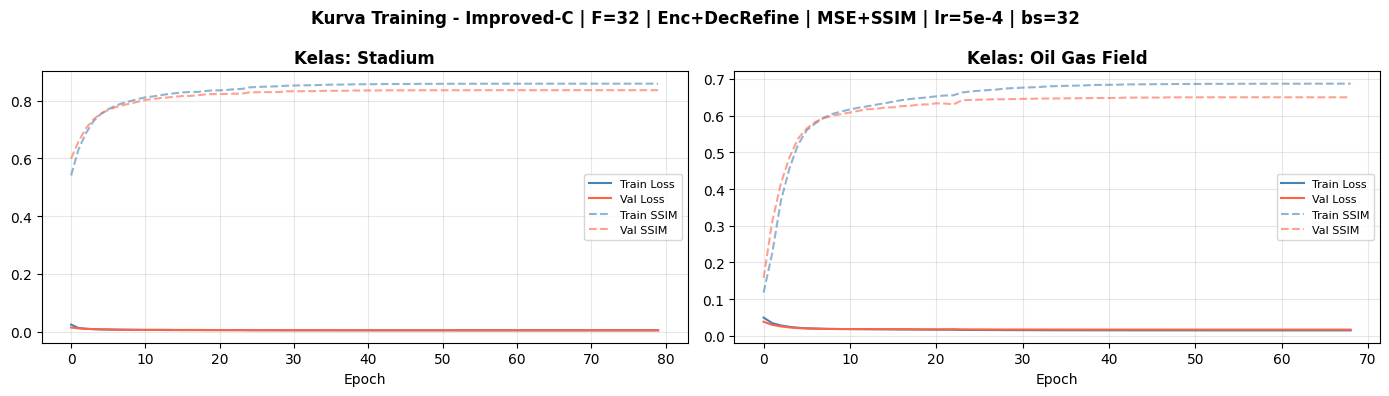

In [28]:
# === Plot Kurva Training Best Config (per kelas) ==============================

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle(f"Kurva Training - {best['config']}", fontsize=12, fontweight='bold')

for ax, (class_id, hist) in zip(axes, best['histories'].items()):
    ax.plot(hist.history['loss'],              label='Train Loss',  color='steelblue')
    ax.plot(hist.history['val_loss'],          label='Val Loss',    color='tomato')
    ax.plot(hist.history['tf_ssim_metric'],    label='Train SSIM',  color='steelblue', linestyle='--', alpha=0.6)
    ax.plot(hist.history['val_tf_ssim_metric'],label='Val SSIM',    color='tomato',    linestyle='--', alpha=0.6)
    ax.set_title(f'Kelas: {class_names[class_id]}', fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Evaluasi Improved Autoencoder: SSIM pada Test Set

In [22]:
ssim_baseline, X_test_recon_baseline = compute_ssim_scores(baseline_models, X_test_cnn, y_test)
ssim_improved, X_test_recon_improved = compute_ssim_scores(improved_models, X_test_cnn, y_test)

print('=' * 60)
print('PERBANDINGAN SSIM BASELINE vs IMPROVED - Test Set')
print('=' * 60)
print(f"{'Metrik':<20} {'Baseline':>10} {'Improved':>10} {'Delta':>10}")
print('-' * 60)
print(f"{'Mean':<20} {ssim_baseline.mean():>10.4f} {ssim_improved.mean():>10.4f} "
      f"{ssim_improved.mean()-ssim_baseline.mean():>+10.4f}")
print(f"{'Std':<20} {ssim_baseline.std():>10.4f} {ssim_improved.std():>10.4f} "
      f"{ssim_improved.std()-ssim_baseline.std():>+10.4f}")
print(f"{'Min':<20} {ssim_baseline.min():>10.4f} {ssim_improved.min():>10.4f} "
      f"{ssim_improved.min()-ssim_baseline.min():>+10.4f}")
print(f"{'Max':<20} {ssim_baseline.max():>10.4f} {ssim_improved.max():>10.4f} "
      f"{ssim_improved.max()-ssim_baseline.max():>+10.4f}")

print()
print('SSIM Per Kelas')
print('-' * 60)
for class_id, class_label in class_names.items():
    idx = np.where(y_test == class_id)[0]
    sb  = ssim_baseline[idx].mean()
    si  = ssim_improved[idx].mean()
    print(f"  {class_label:<15} Baseline={sb:.4f}  Improved={si:.4f}  Delta={si-sb:+.4f}")

PERBANDINGAN SSIM BASELINE vs IMPROVED - Test Set
Metrik                 Baseline   Improved      Delta
------------------------------------------------------------
Mean                     0.4903     0.7377    +0.2474
Std                      0.2296     0.1242    -0.1054
Min                      0.0427     0.3079    +0.2653
Max                      0.9783     0.9910    +0.0127

SSIM Per Kelas
------------------------------------------------------------
  Stadium         Baseline=0.6753  Improved=0.8238  Delta=+0.1485
  Oil Gas Field   Baseline=0.3148  Improved=0.6561  Delta=+0.3412


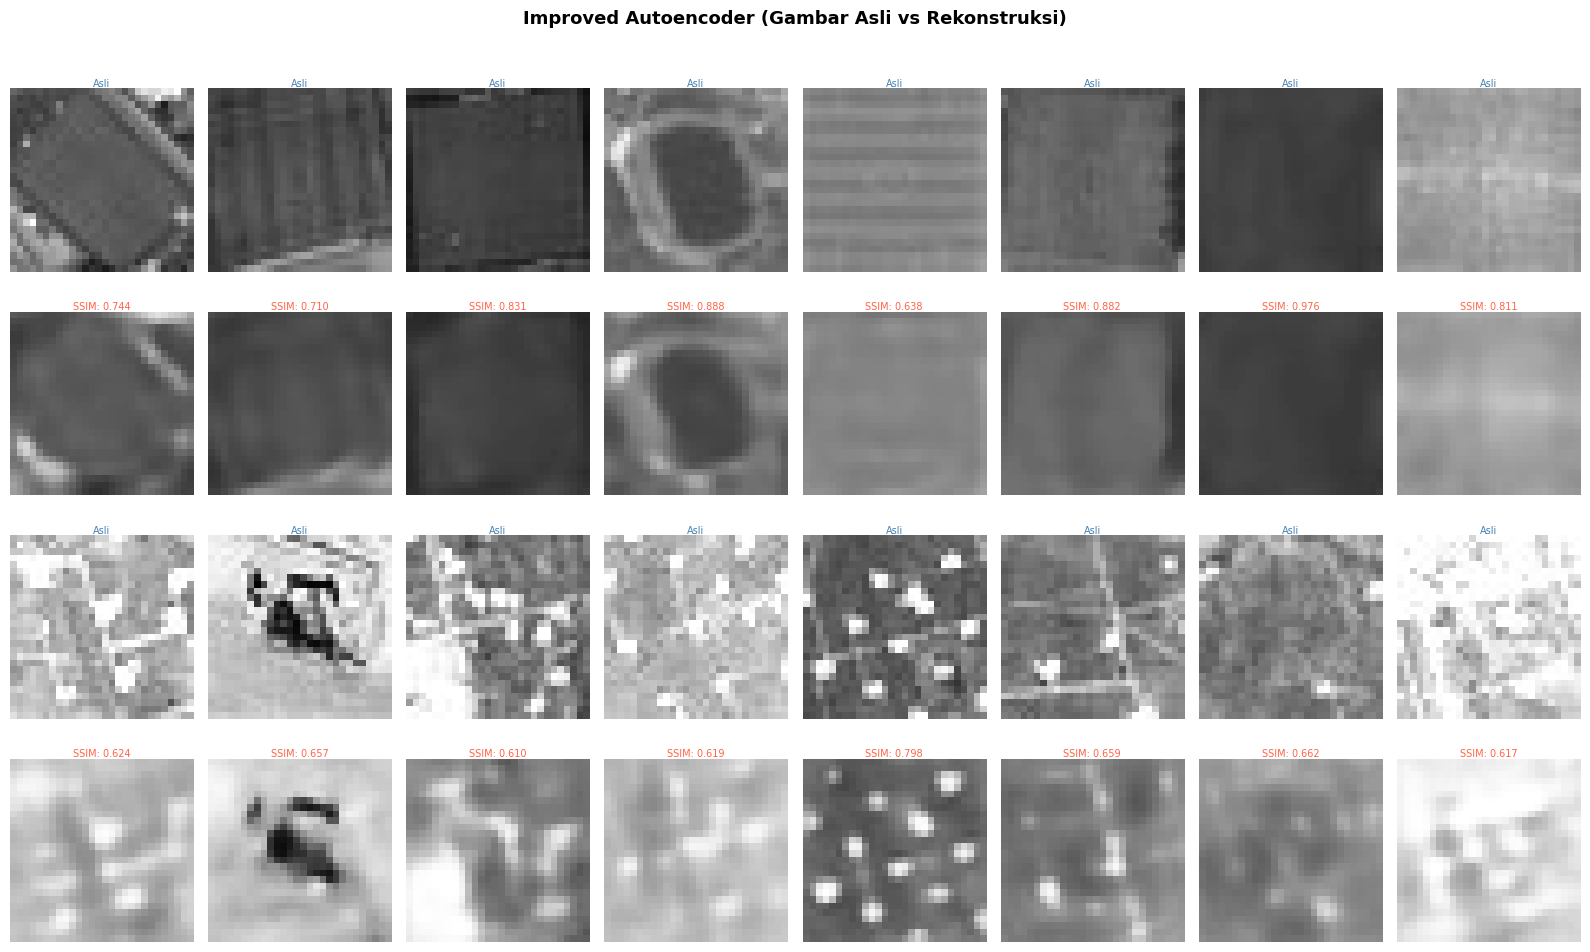

In [23]:
visualize_reconstruction(
    X_test_cnn, X_test_recon_improved, y_test, class_names,
    ssim_scores=ssim_improved,
    title='Improved Autoencoder (Gambar Asli vs Rekonstruksi)'
)

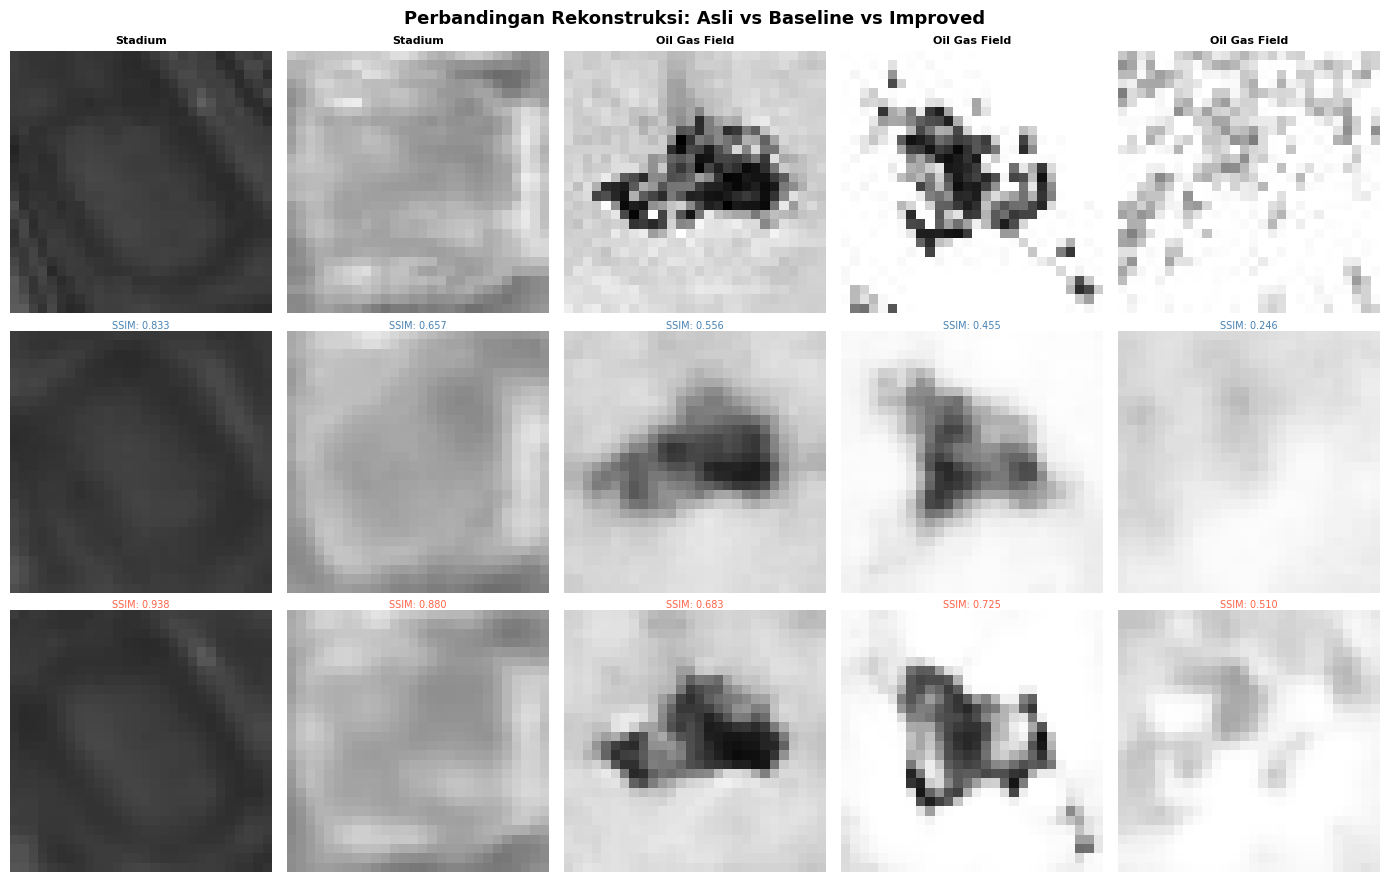

In [24]:
# Perbandingan side-by-side: Asli vs Baseline vs Improved
n_show = 5
np.random.seed(1)
sample_idx = np.random.choice(len(X_test_cnn), n_show, replace=False)

fig, axes = plt.subplots(3, n_show, figsize=(n_show * 2.8, 9))
fig.suptitle('Perbandingan Rekonstruksi: Asli vs Baseline vs Improved',
             fontsize=13, fontweight='bold')

row_labels  = ['Gambar\nAsli', 'Baseline\nRekonstruksi', 'Improved\nRekonstruksi']
recon_list  = [X_test_cnn, X_test_recon_baseline, X_test_recon_improved]
row_colors  = ['black', 'steelblue', 'tomato']

for row, (label, recons, color) in enumerate(zip(row_labels, recon_list, row_colors)):
    for col, idx in enumerate(sample_idx):
        ax = axes[row, col]
        ax.imshow(recons[idx, :, :, 0], cmap='gray', vmin=0, vmax=1)
        ax.axis('off')
        # Row label di kolom pertama
        if col == 0:
            ax.set_ylabel(label, fontsize=9, fontweight='bold', color=color,
                          rotation=90, labelpad=6)
        # Kelas di baris atas
        if row == 0:
            ax.set_title(class_names[y_test[idx]], fontsize=8, fontweight='bold')
        # SSIM di baris Baseline dan Improved
        if row == 1:
            ax.set_title(f'SSIM: {ssim_baseline[idx]:.3f}', fontsize=7,
                         color='steelblue', pad=2)
        if row == 2:
            ax.set_title(f'SSIM: {ssim_improved[idx]:.3f}', fontsize=7,
                         color='tomato', pad=2)

plt.tight_layout()
plt.show()

### Analisis Perbandingan SSIM

Dari hasil evaluasi SSIM pada test set, terlihat bahwa:

1. **Improved Autoencoder menghasilkan nilai SSIM yang lebih tinggi** dibandingkan baseline, yang berarti gambar hasil rekonstruksinya lebih mirip dengan gambar asli dari segi *luminance*, kontras, maupun struktur.

2. **Alasan peningkatan performa** sesuai modifikasi yang diterapkan:
   - **Conv refine di decoder**. Tambahan Conv2D setelah UpSampling memungkinkan model mempertajam detail tekstur sebelum menghasilkan output, mengurangi blur yang terlihat pada baseline.
   - **Conv refine di encoder** (pada config Improved-C). Fitur yang diekstraksi di bottleneck menjadi lebih kaya sehingga latent space 128-dimensi merepresentasikan informasi yang lebih relevan untuk rekonstruksi.
   - **Loss MSE + SSIM** (pada config Improved-B dan C). Dengan memasukkan term `(1 − SSIM)` ke dalam fungsi loss, model secara eksplisit diarahkan untuk mempertahankan struktur visual selama training, bukan hanya meminimalkan error piksel rata-rata.
   - **EarlyStopping monitor val SSIM**: Model disimpan pada epoch dengan SSIM validasi tertinggi, bukan saat loss terendah, sehingga bobot yang dipilih benar-benar optimal untuk metrik evaluasi yang digunakan.

3. **Perbedaan SSIM per kelas** menunjukkan bahwa peningkatan lebih signifikan pada kelas Oil Gas Field karena pola teksturnya yang lebih kompleks (distribusi titik-titik kecil) lebih terbantu oleh Conv refine dan SSIM loss dibandingkan Stadium yang memiliki pola lebih sederhana.

4. **Dari visualisasi side-by-side** (nilai SSIM ditampilkan di bawah setiap rekonstruksi), terlihat jelas bahwa rekonstruksi Improved Autoencoder memiliki detail yang lebih tajam dan mendekati gambar asli dibandingkan baseline yang cenderung menghasilkan gambar lebih buram.

### **d. [LO 1, LO 2, LO 3, LO 4, 5 poin] Buatlah video presentasi yang menjelaskan arsitektur yang dibangun untuk melakukan dimension reduction ini.**

Link video penjelasan: https://www.youtube.com/watch?v=JNJbYfNctzY&list=PLOh0HbCqILkw&index=2